# 3. Plotting, analysis and STAC interoperability

The client ships four plots, all drawn against a country basemap:
`plot_coverage()`, `plot_timeline()`, `plot_providers()` and
`Scene.plot_footprint()`. Each returns a matplotlib `Axes` and accepts `ax=`, so
they compose into your own figures.

The backend is also a real STAC catalog, so standard tooling reads it with or
without this client.

```bash
pip install 'open-sar-triad[notebooks]'
```

In [1]:
# Point at the hosted API, or a local build for testing.
#   BASE = 'http://localhost:8000/api/v1'   # after: python3 -m http.server 8000
BASE = None

from opensartriad import Catalog

cat = Catalog(BASE) if BASE else Catalog()
cat

Catalog('https://www.pmuguda.com/open-sar-triad/api/v1')

## Into pandas

`to_dataframe()` gives the index-level fields, which is enough for most analysis
and does not trigger the lazy per-provider fetch.

In [2]:
df = cat.all().to_dataframe()
print(df.shape)
df.head()

(14859, 11)


,id,provider,date,mode,orbit,look,formats,west,south,east,north
0,ICEYE_4EKGVZ_20251110T124428Z_7004635_X42_SLEDF,iceye,2025-11-10,spotlight,descending,right,"GRD,SLC,CSI,VID",-60.6620,-71.0467,-60.4715,-70.9847
1,ICEYE_6GYF4C_20251014T015405Z_6535129_X31_SLEDF,iceye,2025-10-14,spotlight,ascending,right,"GRD,SLC,CSI,VID",-46.6630,-23.5738,-46.6047,-23.5200
2,ICEYE_6M6S6E_20251104T174449Z_6896483_X55_SLEDF,iceye,2025-11-04,spotlight,descending,right,"GRD,SLC,CSI,VID",-75.1444,-14.7268,-75.0889,-14.6728
3,ICEYE_6Q31WW_20251110T182058Z_7010715_X56_SLEDF,iceye,2025-11-10,spotlight,descending,left,"GRD,SLC,CSI,VID",-77.0845,-9.5688,-77.0311,-9.5158
4,ICEYE_6QE022_20260331T033546Z_9417828_X44_SLEDF,iceye,2026-03-31,spotlight,ascending,left,"GRD,SLC,CSI,VID",-74.5459,-8.4197,-74.4927,-8.3667


In [3]:
df.groupby('provider').size().sort_values(ascending=False)

provider
umbra      11895
capella     2464
iceye        500
dtype: int64

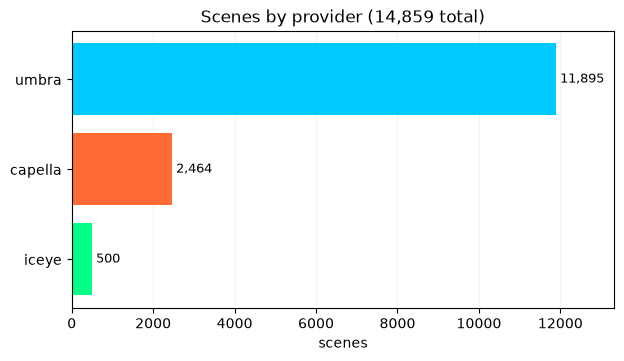

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

cat.all().plot_providers()
plt.show()

## Plotting

The client ships plots for the usual questions, so none of this is hand-rolled.
They need matplotlib: `pip install 'open-sar-triad[plot]'`.

Every plot returns a matplotlib `Axes` and accepts `ax=`, so they compose into
your own figures.

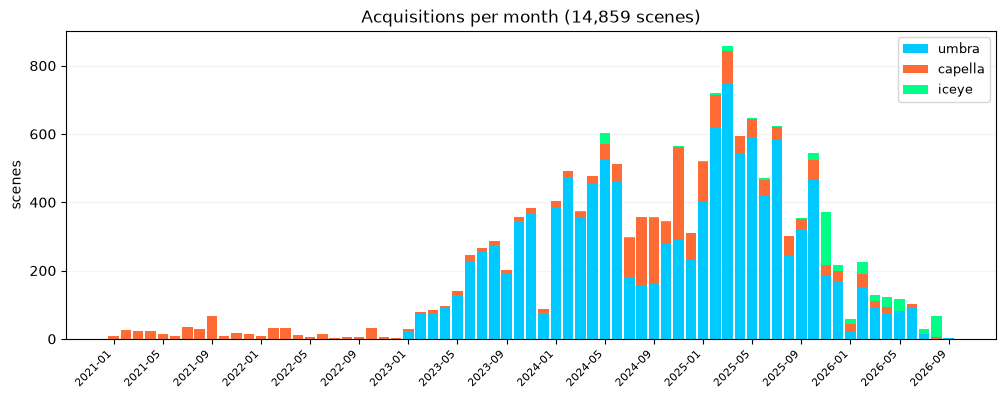

In [5]:
scenes = cat.all()
scenes.plot_timeline(freq='month')
plt.show()

## Sensor modes by provider

In [6]:
pivot = df.groupby(['provider', 'mode']).size().unstack(fill_value=0)
pivot

mode,scan,sliding_spotlight,spotlight,stripmap
provider,,,,
capella,0,258,1909,297
iceye,21,0,401,78
umbra,0,0,11885,10


## Where the scenes are

`plot_coverage()` draws footprints on a country basemap, coloured by provider.

The basemap is the same world-atlas geometry the web map uses, decoded here rather
than pulling in cartopy or contextily. It is cached after the first call, and if
every mirror is blocked the scenes still plot, just without the outlines.

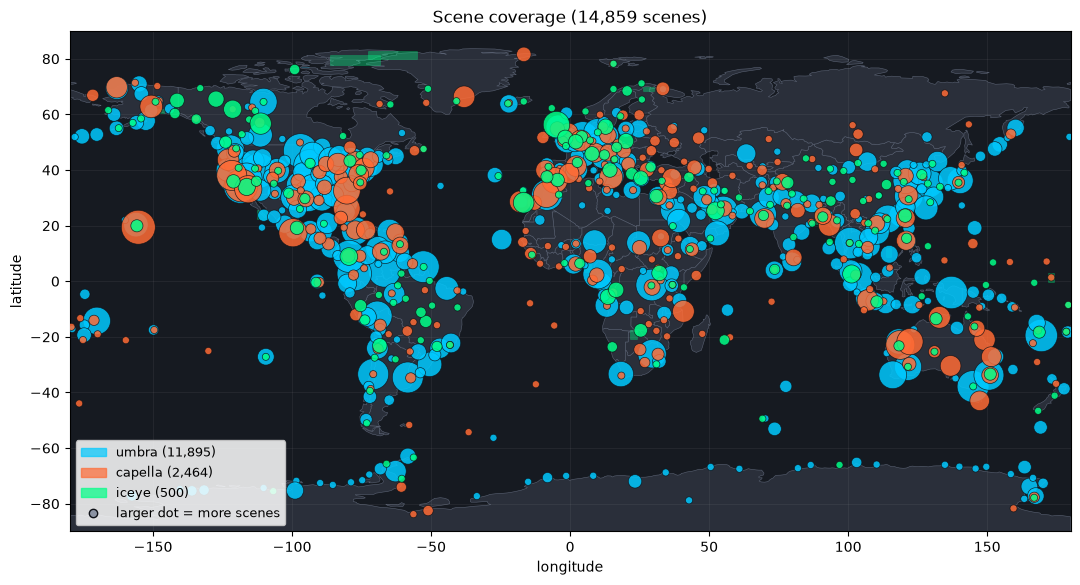

In [7]:
scenes.plot_coverage()
plt.show()

### Zooming in

Pass a `bbox` to focus on an area, and `footprints=True` for true acquisition
polygons instead of bounding boxes (this fetches the full records, so it is slower).

SceneCollection(1180 scenes; umbra 802, capella 245, iceye 133; 2021-02-12 to 2026-09-01)


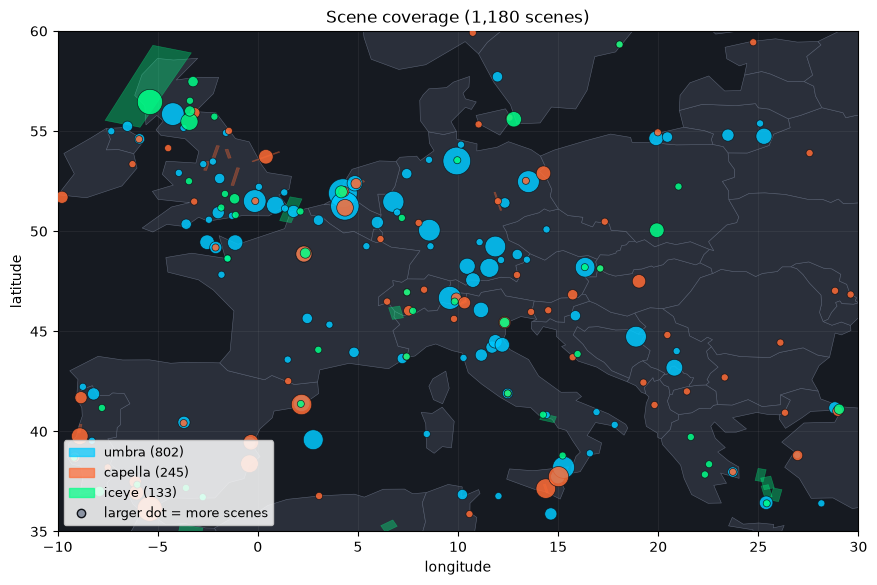

In [8]:
europe = cat.search(bbox=(-10, 35, 30, 60))
print(europe)
europe.plot_coverage(bbox=(-10, 35, 30, 60), footprints=True)
plt.show()

### Composing your own figure

Because each plot returns an `Axes` and accepts `ax=`, they drop into subplots.

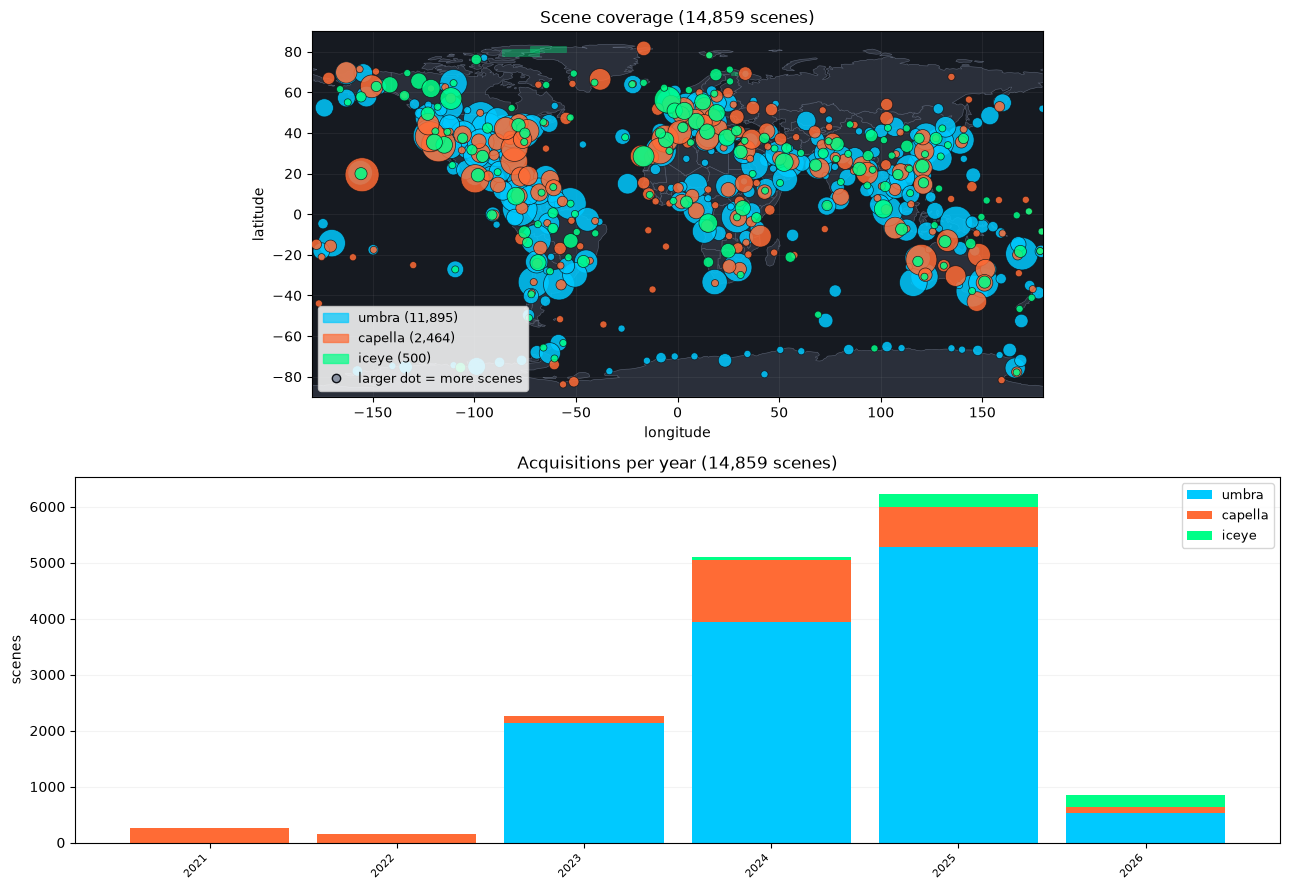

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
scenes.plot_coverage(ax=axes[0])
scenes.plot_timeline(ax=axes[1], freq='year')
plt.tight_layout()
plt.show()

### A single scene

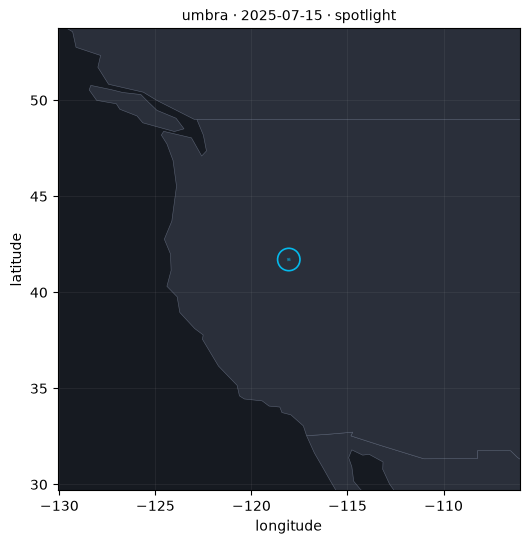

In [10]:
s = cat.search(providers='umbra', limit=1)[0]
s.plot_footprint(pad=12)
plt.show()

## Which products are available

How many scenes can satisfy each family. This is the honest answer to
'can I get complex data here?'

In [11]:
from opensartriad import FAMILIES

rows = []
for fam in FAMILIES:
    hits = cat.search(family=fam)
    by_p = {}
    for s in hits:
        by_p[s.provider] = by_p.get(s.provider, 0) + 1
    rows.append({'family': fam, 'total': len(hits), **by_p})

import pandas as pd
pd.DataFrame(rows).set_index('family').fillna(0).astype(int)

,total,iceye,umbra,capella
family,,,,
detected,14759,500,11895,2364
complex,14661,479,11895,2287
phase,13078,6,11895,1177
visual,12231,324,11895,12


## STAC interoperability

Search results convert straight to a STAC ItemCollection.

In [12]:
sel = cat.search(bbox=(5.9, 47.2, 10.5, 55.1), start='2025-01-01', limit=5)
ic = sel.to_stac()

print(ic['type'], '| stac_version', ic['stac_version'], '|', len(ic['features']), 'items')
item = ic['features'][0]
print('id      :', item['id'])
print('assets  :', list(item['assets'])[:6])
print('bbox    :', item['bbox'])

FeatureCollection | stac_version 1.0.0 | 5 items
id      : ICEYE_U1J05X_20251109T212114Z_6992608_X42_SLP3L
assets  : ['GRD', 'GRD_metadata', 'CSI', 'CSI_metadata', 'SLC', 'SLC_metadata']
bbox    : [7.1494, 50.6358, 7.2387, 50.6926]


### Using pystac directly

No client needed. Any STAC tool can read the catalog by URL.

```python
import pystac

root = pystac.Catalog.from_file(
    'https://www.pmuguda.com/open-sar-triad/api/v1/catalog.json'
)
for child in root.get_children():
    print(child.id, '-', child.title)
```

## Licence

Scene metadata is CC-BY 4.0. Credit the originating provider in published work.

In [13]:
print(cat.license()['attribution'])

Scene metadata (c) ICEYE, Umbra and Capella, published under their open data programs and licensed CC-BY 4.0. Catalog assembled by open-sar-triad (https://github.com/pmuguda/open-sar-triad) from normalized STAC records maintained by Jack-Hayes/commerical-sar-stac (MIT). When redistributing this data or publishing derived work, credit the originating provider.
